# Yield prediction model comparison: OLS, Ridge, Random Forest, Ridge+PCA

This notebook trains and compares four models to predict **Mean_Yield**:

1. **OLS** (ordinary least squares)
2. **Ridge** (L2-regularized linear regression)
3. **Random Forest** (non-linear ensemble)
4. **Ridge + PCA** (principal components on numeric climate features + ridge)

The goal is to make the comparison **easy to visualize** with:
- a compact metrics table
- bar charts (R², RMSE)
- predicted vs actual plots for each model

> Notes
> - This notebook assumes your data file is named `yields_weather_by_crop.csv` and exists in a `prepared/` folder (or nearby).
> - It automatically detects categorical columns (like `Municipality`, `Crop`) and one-hot encodes them.
> - It applies scaling only where needed (linear models).


In [20]:
# === Imports ===
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.decomposition import PCA

from sklearn.metrics import mean_squared_error, r2_score

import matplotlib.pyplot as plt


In [21]:
# === Load data ===
data_path = "../data/prepared/dataset_reanalysis_muni_year.csv"

df = pd.read_csv(data_path)
print("Shape:", df.shape)
df.head()


Shape: (1325, 379)


,Municipality,Year,Yield_restated,Tmax_max_May,Tmax_min_May,Tmax_avg_May,Tmin_max_May,Tmin_min_May,Tmin_avg_May,Tavg_max_May,...,DGDH4_max_GS,DGDH4_avg_GS,DGDH4_<lambda_0>_GS,DGDH5_max_GS,DGDH5_avg_GS,DGDH5_<lambda_0>_GS,PREH_avg_GS,PREH_<lambda_0>_GS,PREL_avg_GS,PREL_<lambda_0>_GS
0,ALEXANDER,1996,0.907619,24.521454,7.414547,14.748748,14.290596,-3.382574,4.204085,19.406025,...,5.526901,0.079913,11,4.526901,0.038507,5,0.002953,106,-5.807609e-11,78
1,ALEXANDER,1997,0.859800,27.574864,4.090314,13.785039,17.245849,-2.878021,3.392953,22.410357,...,2.534680,0.034798,6,1.534680,0.010103,2,0.003170,113,-3.723641e-11,71
2,ALEXANDER,1998,0.938502,24.629440,10.476053,18.568872,14.299995,0.074379,7.772190,18.913306,...,1.971862,0.037731,7,0.971862,0.006662,3,0.002805,123,-6.066848e-11,61
3,ALEXANDER,1999,1.013855,27.969421,6.139760,16.413447,16.607863,-1.397309,8.158129,22.288642,...,4.457402,0.068923,8,3.457402,0.030677,5,0.002815,127,-3.469565e-11,57
4,ALEXANDER,2000,0.713670,24.544319,4.963565,16.681179,15.934887,0.125813,6.624320,20.239603,...,1.337081,0.022008,6,0.337081,0.003227,2,0.003557,122,-4.548913e-11,62


In [22]:
# === Split features/target ===
TARGET = "Yield_restated"

y = df[TARGET]
X = df.drop(columns=[TARGET])

# Identify categorical vs numeric
cat_cols = [c for c in X.columns if X[c].dtype == "object" or str(X[c].dtype).startswith("category")]
num_cols = [c for c in X.columns if c not in cat_cols]

print(f"Numeric columns: {len(num_cols)}")
print(f"Categorical columns: {len(cat_cols)}")
print("Categorical columns:", cat_cols)


Numeric columns: 377
Categorical columns: 1
Categorical columns: ['Municipality']


In [23]:
# === Train/test split ===
# If you prefer time-aware splitting (e.g., by Year), adapt this section.

RANDOM_STATE = 42
TEST_SIZE = 0.2

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

print("Train size:", X_train.shape, "Test size:", X_test.shape)


Train size: (1060, 378) Test size: (265, 378)


## Preprocessing

We use a **ColumnTransformer**:

- **Numeric**: median imputation + (optionally) scaling
- **Categorical**: most-frequent imputation + one-hot encoding

Scaling is applied for linear models (OLS/Ridge/Ridge+PCA). Random Forest does not need scaling.


In [24]:
# === Preprocessing blocks ===

numeric_imputer = SimpleImputer(strategy="median")

categorical_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

preprocess_for_linear = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("impute", numeric_imputer), ("scale", StandardScaler())]), num_cols),
        ("cat", Pipeline([("onehot", categorical_encoder)]), cat_cols),
    ],
    remainder="drop",
)

preprocess_for_rf = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("impute", numeric_imputer)]), num_cols),
        ("cat", Pipeline([("onehot", categorical_encoder)]), cat_cols),
    ],
    remainder="drop",
)


## Models

- **OLS**: `LinearRegression()`
- **Ridge**: `Ridge(alpha=...)`
- **Random Forest**: `RandomForestRegressor(...)`
- **Ridge + PCA**: PCA is applied **only to numeric features** (after scaling), then concatenated with one-hot categorical features, then Ridge.

We keep the hyperparameters simple and reasonable as a baseline.


In [25]:
# === Define model pipelines ===

ols = Pipeline([
    ("prep", preprocess_for_linear),
    ("model", LinearRegression()),
])

ridge = Pipeline([
    ("prep", preprocess_for_linear),
    ("model", Ridge(alpha=1.0, random_state=RANDOM_STATE)),
])

rf = Pipeline([
    ("prep", preprocess_for_rf),
    ("model", RandomForestRegressor(
        n_estimators=500,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        min_samples_leaf=2,
    )),
])

# Ridge + PCA: build a transformer that applies PCA only to numeric block
numeric_pca = Pipeline([
    ("impute", numeric_imputer),
    ("scale", StandardScaler()),
    ("pca", PCA(n_components=0.95, random_state=RANDOM_STATE)),  # keep 95% variance
])

prep_ridge_pca = ColumnTransformer(
    transformers=[
        ("num_pca", numeric_pca, num_cols),
        ("cat", Pipeline([ ("onehot", categorical_encoder)]), cat_cols),
    ],
    remainder="drop",
)

ridge_pca = Pipeline([
    ("prep", prep_ridge_pca),
    ("model", Ridge(alpha=1.0, random_state=RANDOM_STATE)),
])

models = {
    "OLS": ols,
    "Ridge": ridge,
    "Random Forest": rf,
    "Ridge + PCA": ridge_pca,
}

list(models.keys())


['OLS', 'Ridge', 'Random Forest', 'Ridge + PCA']

In [26]:
# === Fit + evaluate ===

def evaluate(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    mse = mean_squared_error(y_test, pred)
    rmse = float(np.sqrt(mse))
    r2 = r2_score(y_test, pred)

    return {
        "mse": float(mse),
        "rmse": rmse,
        "r2": float(r2),
        "pred": pred,
        "model": model,
    }

results = {}
for name, m in models.items():
    results[name] = evaluate(m, X_train, y_train, X_test, y_test)

metrics = (
    pd.DataFrame({k: {"R2": v["r2"], "RMSE": v["rmse"], "MSE": v["mse"]} for k, v in results.items()})
      .T
      .sort_values("R2", ascending=False)
)

metrics


,R2,RMSE,MSE
Random Forest,0.604181,0.193353,0.037385
Ridge + PCA,0.476333,0.222398,0.049461
Ridge,0.424821,0.233080,0.054326
OLS,-34492.842619,57.078635,3257.970616


## Easy-to-visualize comparison

1) **Metrics table** (above) sorted by R²

2) **Bar charts** for R² and RMSE

3) **Predicted vs actual** plots (one figure per model)


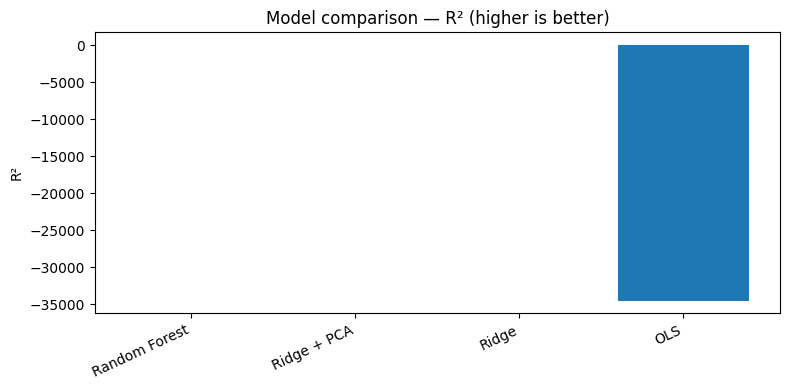

In [27]:
# === Bar chart: R² ===
plt.figure(figsize=(8, 4))
plt.bar(metrics.index, metrics["R2"])
plt.ylabel("R²")
plt.title("Model comparison — R² (higher is better)")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


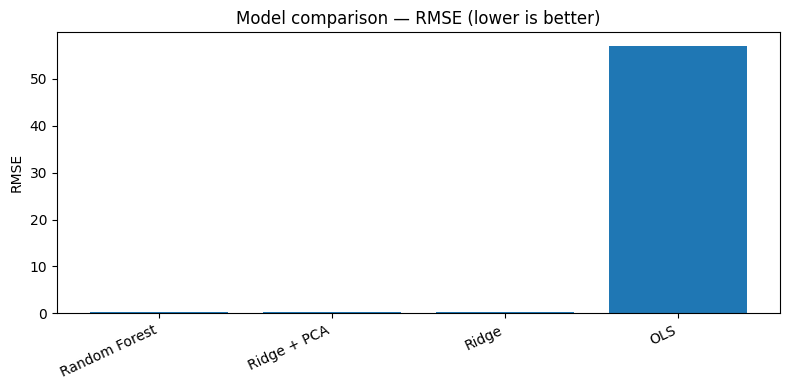

In [28]:
# === Bar chart: RMSE ===
plt.figure(figsize=(8, 4))
plt.bar(metrics.index, metrics["RMSE"])
plt.ylabel("RMSE")
plt.title("Model comparison — RMSE (lower is better)")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


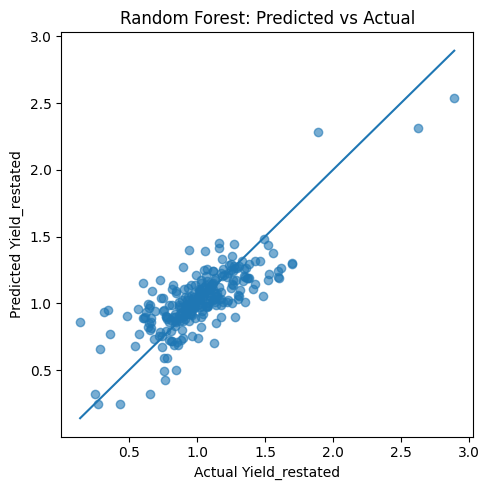

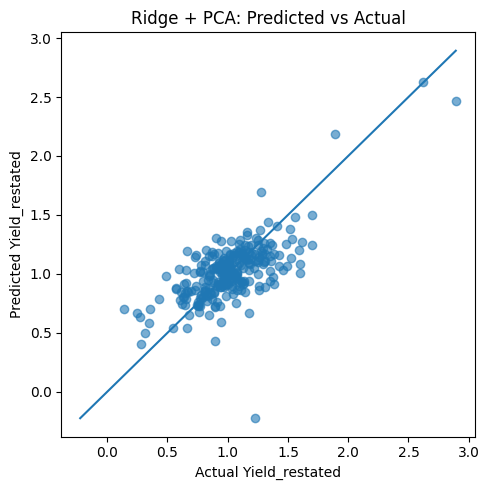

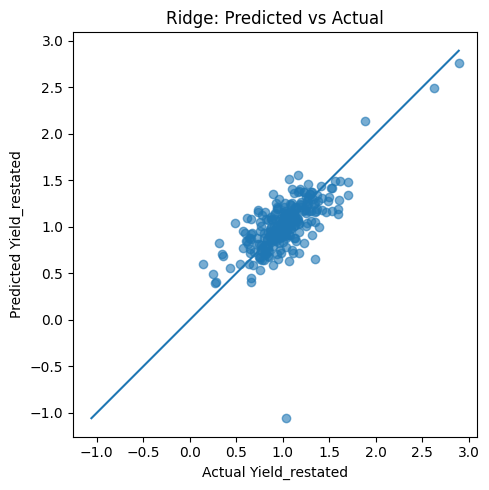

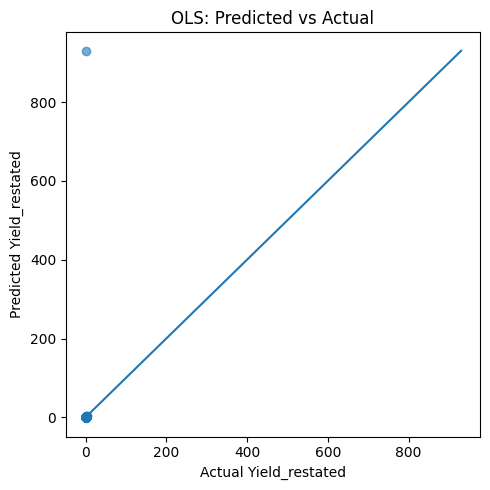

In [29]:
# === Predicted vs Actual (one plot per model) ===

y_true = y_test.values

for name in metrics.index:
    y_pred = results[name]["pred"]

    plt.figure(figsize=(5, 5))
    plt.scatter(y_true, y_pred, alpha=0.6)

    # 45-degree reference line
    lo = float(min(y_true.min(), y_pred.min()))
    hi = float(max(y_true.max(), y_pred.max()))
    plt.plot([lo, hi], [lo, hi])

    plt.xlabel("Actual Yield_restated")
    plt.ylabel("Predicted Yield_restated")
    plt.title(f"{name}: Predicted vs Actual")
    plt.tight_layout()
    plt.show()


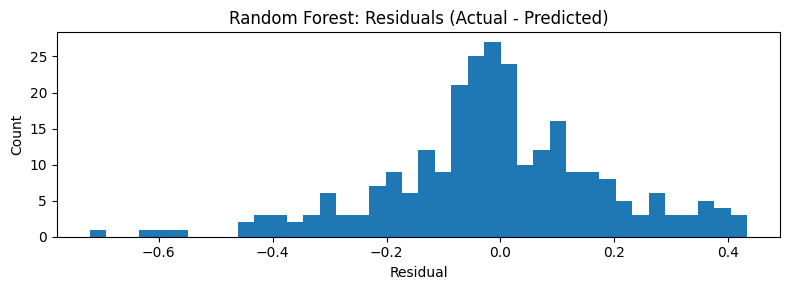

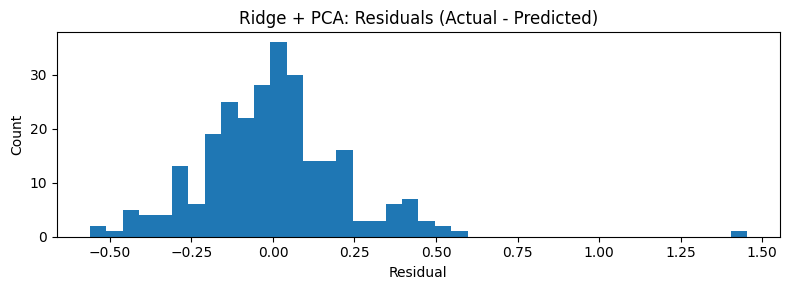

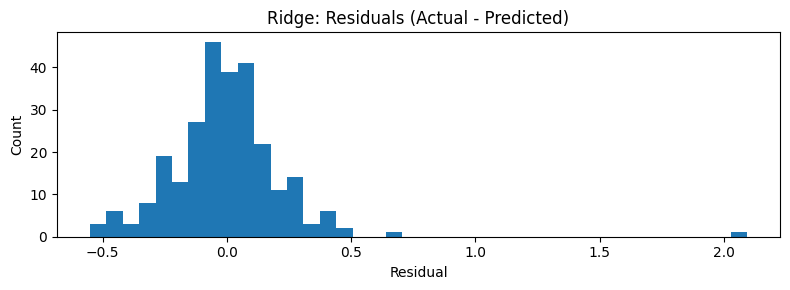

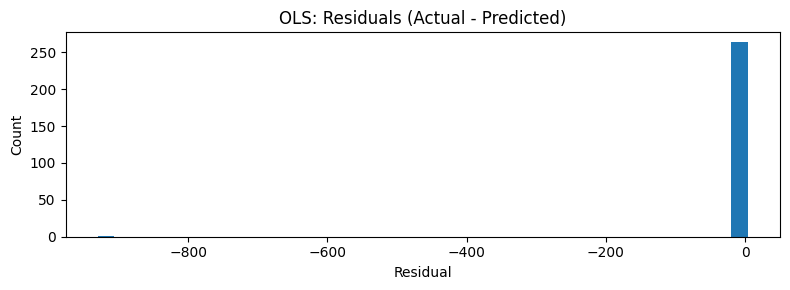

In [30]:
# === (Optional) Residual distribution per model ===
# Useful to see bias and heavy tails.

for name in metrics.index:
    y_pred = results[name]["pred"]
    residuals = y_true - y_pred

    plt.figure(figsize=(8, 3))
    plt.hist(residuals, bins=40)
    plt.title(f"{name}: Residuals (Actual - Predicted)")
    plt.xlabel("Residual")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()


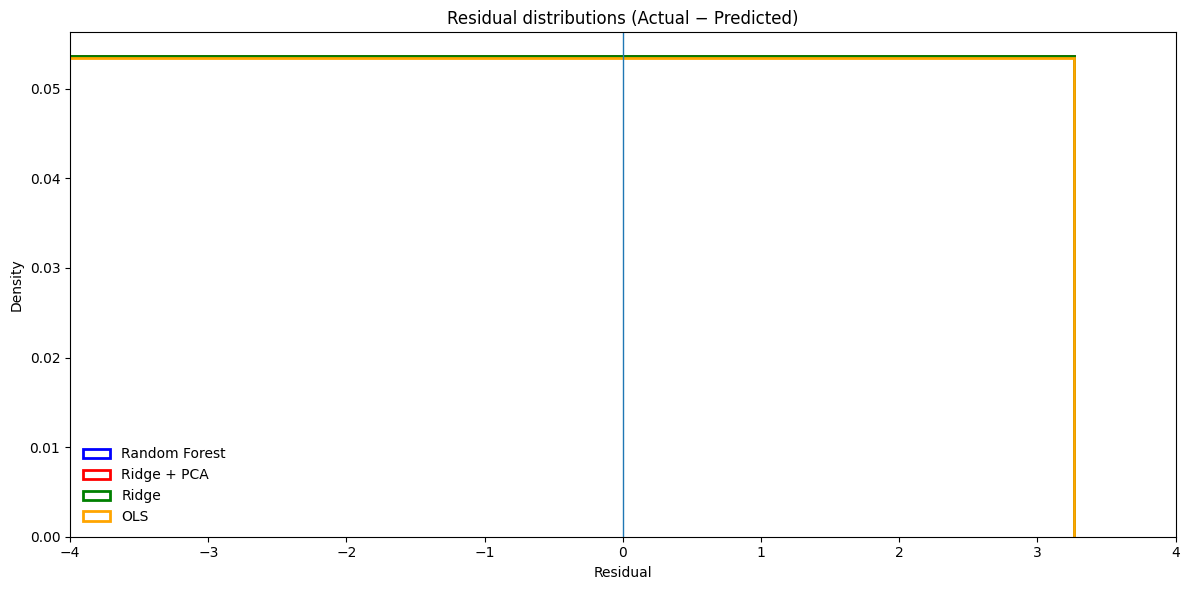

In [31]:
# --- compute residuals for each model ---
residuals_by_model = {}

# --- residuals ---
residuals_by_model = {}
for name in metrics.index:
    y_pred = results[name]["pred"]
    residuals_by_model[name] = y_true - y_pred

# --- common bins ---
all_res = np.concatenate(list(residuals_by_model.values()))
bins = np.histogram_bin_edges(all_res, bins=50)

# --- fixed colors (order matters) ---
colors = ["blue", "red", "green", "orange"]

plt.figure(figsize=(12, 6))

for (name, res), color in zip(residuals_by_model.items(), colors):
    plt.hist(
        res,
        bins=bins,
        histtype="step",
        linewidth=2,
        density=True,
        label=name,
        color=color
    )

plt.axvline(0, linewidth=1)
plt.xlim(-4, 4)

plt.title("Residual distributions (Actual − Predicted)")
plt.xlabel("Residual")
plt.ylabel("Density")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


## Notes on making this comparison more statistically reliable

If your dataset has strong **time structure** (Year) or **group structure** (Municipality), consider:

- **Split by Year** (train on earlier years, test on later years)
- Or **GroupKFold** cross-validation by Year or Municipality

This helps avoid overly-optimistic scores due to leakage-like effects from random splits.
